Leptonic equilibrium
====================

In [1]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pylab as plt
import jetset

In [2]:
print('tested with',jetset.__version__)

tested with 1.4.0rc3


## Setting up the model

In [3]:
from jetset.jet_model import Jet
from jetset.jet_emitters_factory import InjEmittersFactory

q_inj = InjEmittersFactory().create_inj_emitters('pl')
my_jet=Jet(emitters_distribution=q_inj)
my_jet.parameters.p.val=2.2
my_jet.parameters.z_cosm.val=3.080000e-02
my_jet.parameters.R.val=1E16
my_jet.parameters.B.val=.1
my_jet.parameters.L_inj.val=5E38
my_jet.parameters.gmin.val=100
my_jet.parameters.beam_obj.val=25


The model inherits as parameters the parameters of the injected emitters. 

Of course, when creating the `q_inj` object you can use the same approach used for `emitters`, the only difference is that in place of the emitters density `N` you will pas the injected luminosity `L_inj`. **Moreover, the parameter  `T_esc_e_primaries`,  in units of `R/c`, will drive the equilibrium energy**.

In [4]:
my_jet.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,1.000000e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,1.000000e-01,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,2.500000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,3.080000e-02,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,1.000000e+02,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.000000e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,p,LE_spectral_slope,,2.200000e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,T_esc_e_primaries,escape_time,R / c,1.000000e+00,1.000000e+00,--,False,False


None

In [5]:
my_jet.eval()
my_jet.energetic_report()

name,type,units,val
BulkLorentzFactor,jet-bulk-factor,,2.500000e+01
U_e,Energy dens. blob rest. frame,erg / cm3,3.656928e-05
U_p_cold,Energy dens. blob rest. frame,erg / cm3,1.503276e-01
U_B,Energy dens. blob rest. frame,erg / cm3,3.978874e-04
U_Synch,Energy dens. blob rest. frame,erg / cm3,9.898015e-07
U_Synch_DRF,Energy dens. disk rest. frame,erg / cm3,3.866412e-01
U_Disk,Energy dens. blob rest. frame,erg / cm3,0.000000e+00
U_BLR,Energy dens. blob rest. frame,erg / cm3,0.000000e+00
U_DT,Energy dens. blob rest. frame,erg / cm3,0.000000e+00
U_Corona,Energy dens. blob rest. frame,erg / cm3,0.000000e+00


As in the case of standard jet model, we can rescale ``L_inj`` according to the desired energy density of the emitters

In [6]:
print(my_jet.parameters.L_inj.val)
my_jet.set_N_from_U_emitters(1E-3)
my_jet.eval()
print(my_jet.parameters.L_inj.val)


5e+38
1.353837527642013e+40


Or according to the desired energy density of the emitters


1.353837527642013e+40
5.895413484370994e+39


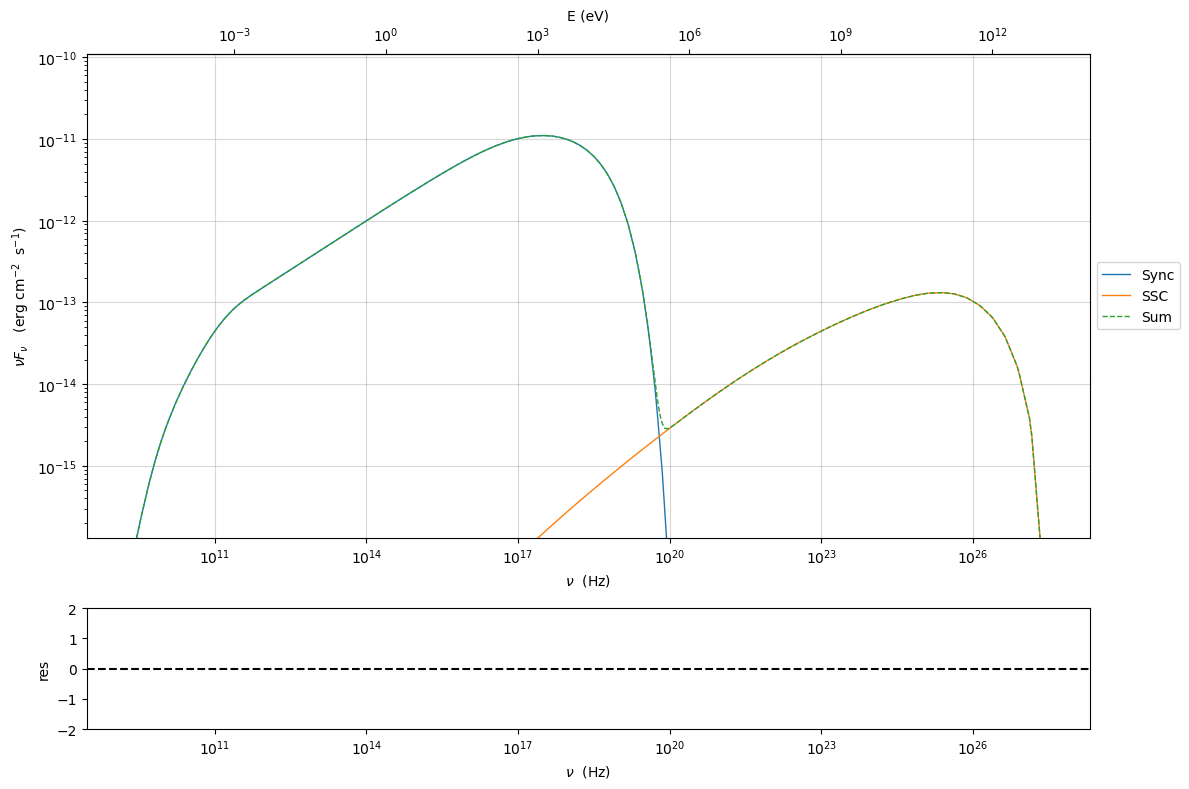

In [7]:
print(my_jet.parameters.L_inj.val)
my_jet.set_N_from_nuFnu(nu_obs=1E14,nuFnu_obs=1E-12)
my_jet.eval()
print(my_jet.parameters.L_inj.val)
my_jet.plot_model()


You can easily plot both the injected distribution and the equilibrium one

231979.40174924445


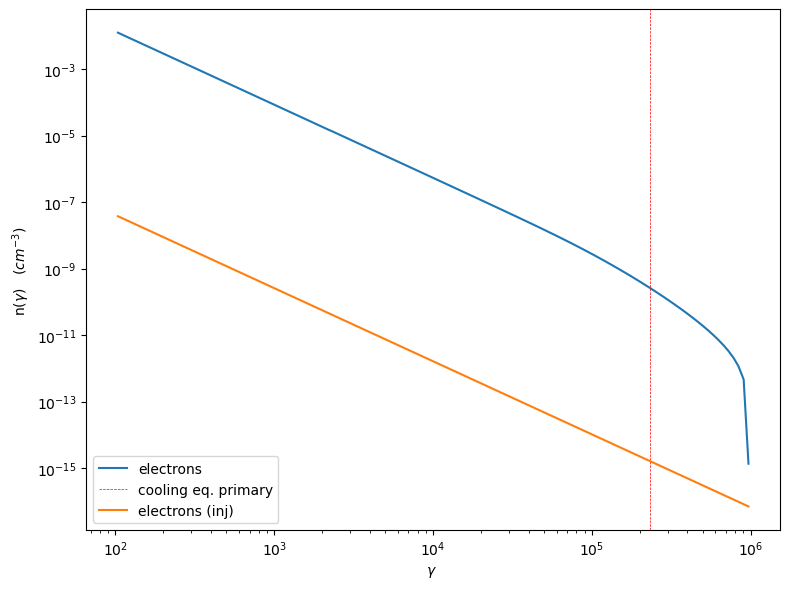

In [8]:
my_jet.eval()
my_jet.emitters_distribution.plot()
print(my_jet.emitters_distribution.gamma_cooling_eq)


9279.17606996978


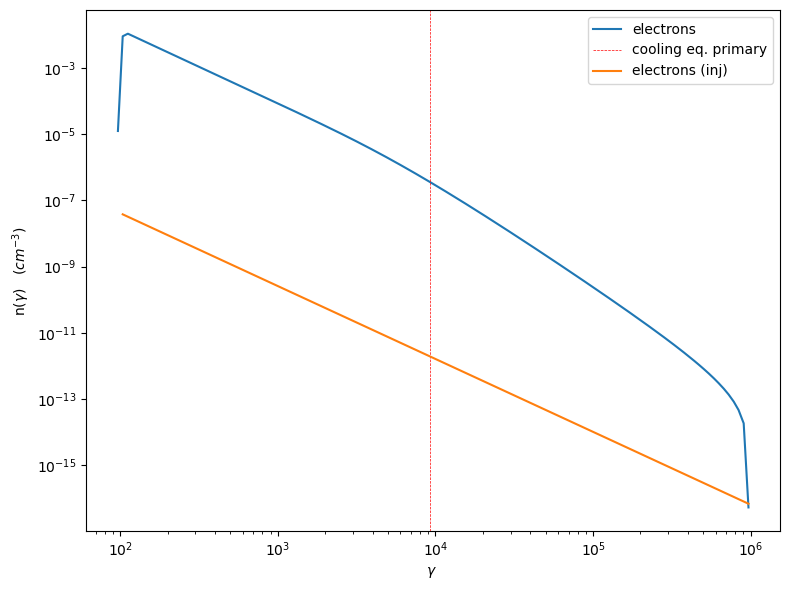

In [9]:
my_jet.parameters.B.val=.5
my_jet.eval()
my_jet.emitters_distribution.plot()
print(my_jet.emitters_distribution.gamma_cooling_eq)


The SED at the equilibrium:

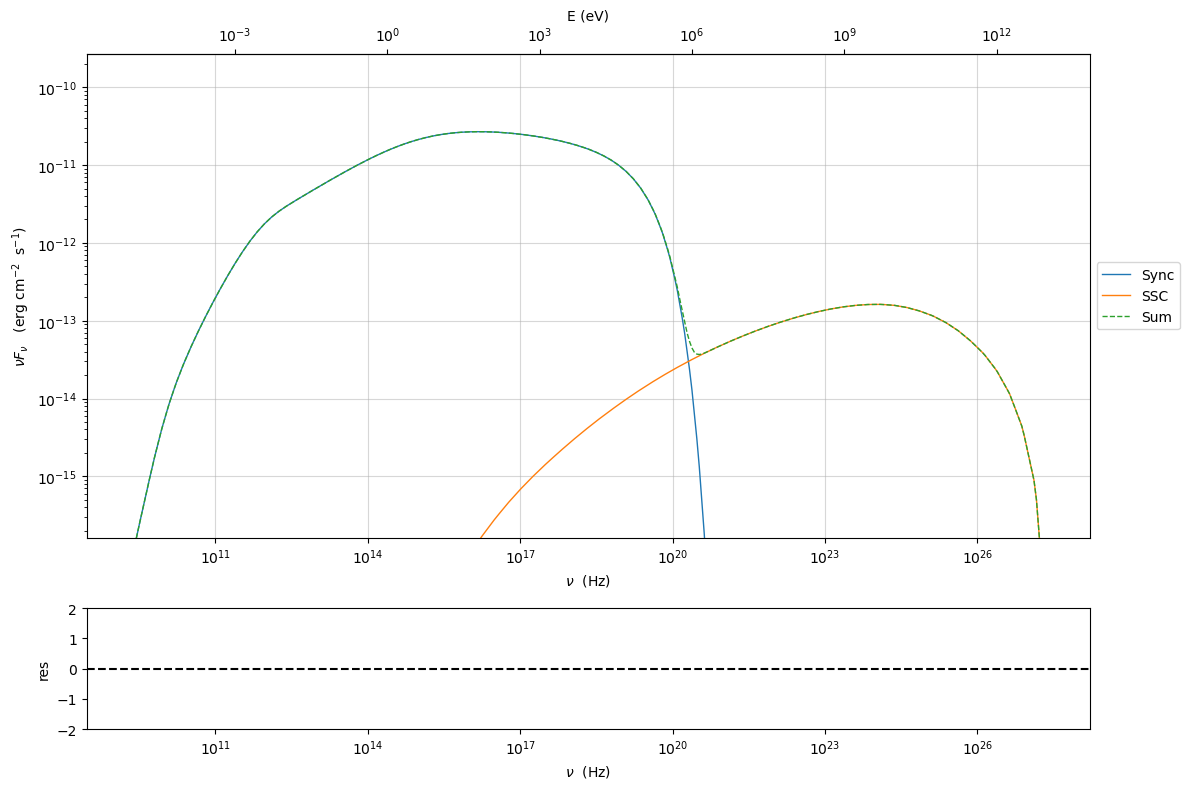

In [10]:
my_jet.eval()
my_jet.plot_model()

### Computational speed

In [11]:
%timeit my_jet.eval()


11.1 ms ± 96.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [12]:
j=Jet()

%timeit j.eval()


1.55 ms ± 55.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


The overhead time for equilibrium computation, compared to a standard leptonic model, is of a factor ~ 5, but still capable of ~ 100 evaluation per second (Apple Silicon M4 pro with C threads).